# Week 10 Jupyter Notebook — Clustering 1: K-Means

## Integrated Capstone Project: Wisconsin and Coimbra Breast Cancer Datasets

**Week topic:** K-means clustering, elbow method, silhouette score, feature scaling, and distance metrics

### Notebook purpose

For Week 10, I am applying **K-means clustering** to both capstone datasets:

1. **Breast Cancer Wisconsin Diagnostic dataset** — tumor image-based measurements.
2. **Breast Cancer Coimbra dataset** — clinical and blood-based biomarkers.

K-means is different from the supervised models used in earlier weeks because it does **not** use the diagnosis label when creating clusters. After clustering, I compare the clusters to the known diagnosis labels only for interpretation.

The main goal is to see whether the data naturally groups itself in a way that resembles the known cancer/non-cancer outcome.


## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


## 2. Helper functions

These helper functions are used for both datasets.

Important note: standard K-means is based on Euclidean distance because it minimizes within-cluster squared distances. I still compare distance metrics by calculating silhouette scores using Euclidean, Manhattan, and cosine distances after the clusters are created.


In [2]:
def scale_data(X, method):
    if method == "none":
        return pd.DataFrame(X.copy(), columns=X.columns, index=X.index)
    elif method == "standard":
        scaler = StandardScaler()
    elif method == "minmax":
        scaler = MinMaxScaler()
    else:
        raise ValueError("Use method='none', 'standard', or 'minmax'.")

    X_scaled = scaler.fit_transform(X)
    return pd.DataFrame(X_scaled, columns=X.columns, index=X.index)


def run_kmeans(X_scaled, k):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    return model, labels


def elbow_and_silhouette(X_scaled, k_values):
    rows = []
    for k in k_values:
        model, labels = run_kmeans(X_scaled, k)
        rows.append({
            "k": k,
            "inertia": model.inertia_,
            "silhouette_euclidean": silhouette_score(X_scaled, labels, metric="euclidean")
        })
    return pd.DataFrame(rows)


def compare_distance_metrics(X_scaled, labels):
    rows = []
    for metric in ["euclidean", "manhattan", "cosine"]:
        rows.append({
            "distance_metric": metric,
            "silhouette_score": silhouette_score(X_scaled, labels, metric=metric)
        })
    return pd.DataFrame(rows).sort_values("silhouette_score", ascending=False)


def compare_clusters_to_labels(labels, y_true, dataset_name):
    return {
        "dataset": dataset_name,
        "adjusted_rand_index": adjusted_rand_score(y_true, labels),
        "normalized_mutual_info": normalized_mutual_info_score(y_true, labels)
    }


def plot_pca_view(X_scaled, labels, y_true, dataset_name, class_names):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame({
        "PC1": coords[:, 0],
        "PC2": coords[:, 1],
        "cluster": labels,
        "true_label": y_true
    })

    plt.figure(figsize=(8, 6))
    for cluster in sorted(pca_df["cluster"].unique()):
        group = pca_df[pca_df["cluster"] == cluster]
        plt.scatter(group["PC1"], group["PC2"], alpha=0.75, label=f"Cluster {cluster}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"{dataset_name}: K-Means Clusters in PCA Space")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    for value, label in class_names.items():
        group = pca_df[pca_df["true_label"] == value]
        plt.scatter(group["PC1"], group["PC2"], alpha=0.75, label=label)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"{dataset_name}: Known Labels in PCA Space")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return pca_df


# Part A — Wisconsin Dataset

## 3. Load Wisconsin dataset

The sklearn target is originally coded as `0 = malignant` and `1 = benign`. I recode it so that `1 = malignant` and `0 = benign`.


In [3]:
cancer = load_breast_cancer()

wisconsin_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
wisconsin_df.columns = wisconsin_df.columns.str.replace(" ", "_")

wisconsin_df["diagnosis_malignant"] = (cancer.target == 0).astype(int)
wisconsin_df["diagnosis_label"] = np.where(wisconsin_df["diagnosis_malignant"] == 1, "Malignant", "Benign")

print("Wisconsin shape:", wisconsin_df.shape)
print(wisconsin_df["diagnosis_label"].value_counts())
wisconsin_df.head()


Wisconsin shape: (569, 32)
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis_malignant,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,Malignant


## 4. Wisconsin features and target label

The diagnosis label is not used to form clusters. It is saved only so I can compare the unsupervised clusters back to the known diagnosis later.


In [4]:
wisconsin_features = [c for c in wisconsin_df.columns if c not in ["diagnosis_malignant", "diagnosis_label"]]

X_w = wisconsin_df[wisconsin_features]
y_w = wisconsin_df["diagnosis_malignant"]

print("Wisconsin rows:", X_w.shape[0])
print("Wisconsin features:", X_w.shape[1])


Wisconsin rows: 569
Wisconsin features: 30


## 5. Wisconsin feature scaling check

K-means depends on distance, so features with larger numeric ranges can dominate the clustering if the data are not scaled.


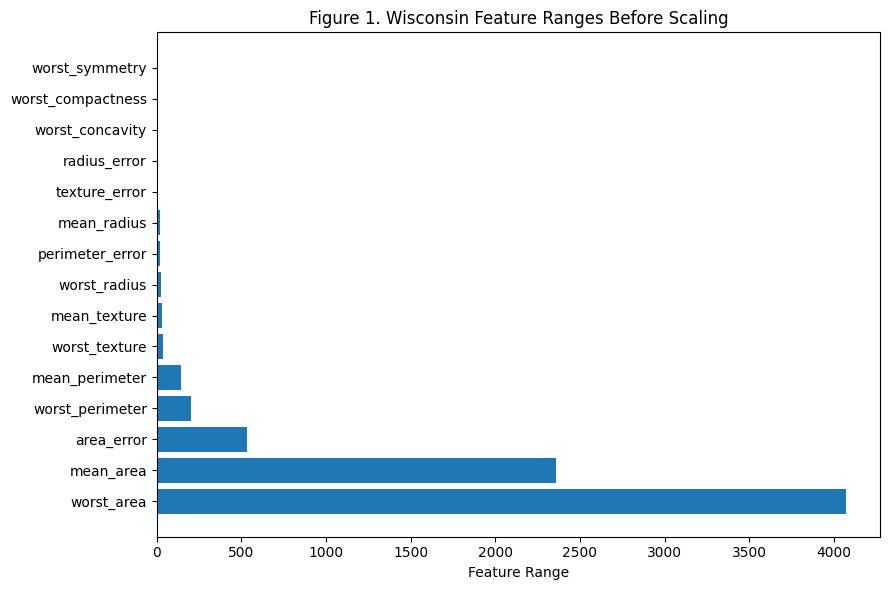

,min,max,mean,std,range
worst_area,185.20000,4254.0000,880.583128,569.356993,4068.80000
mean_area,143.50000,2501.0000,654.889104,351.914129,2357.50000
area_error,6.80200,542.2000,40.337079,45.491006,535.39800
worst_perimeter,50.41000,251.2000,107.261213,33.602542,200.79000
mean_perimeter,43.79000,188.5000,91.969033,24.298981,144.71000
worst_texture,12.02000,49.5400,25.677223,6.146258,37.52000
mean_texture,9.71000,39.2800,19.289649,4.301036,29.57000
worst_radius,7.93000,36.0400,16.269190,4.833242,28.11000
perimeter_error,0.75700,21.9800,2.866059,2.021855,21.22300
mean_radius,6.98100,28.1100,14.127292,3.524049,21.12900


In [5]:
w_scale = X_w.agg(["min", "max", "mean", "std"]).T
w_scale["range"] = w_scale["max"] - w_scale["min"]
w_scale = w_scale.sort_values("range", ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(w_scale.index, w_scale["range"])
plt.xlabel("Feature Range")
plt.title("Figure 1. Wisconsin Feature Ranges Before Scaling")
plt.tight_layout()
plt.show()

w_scale


## 6. Wisconsin scaling comparison with k = 2

Because the known outcome has two groups, I first compare K-means with `k = 2` using no scaling, standard scaling, and min-max scaling.


In [6]:
w_scaling_results = []

for method in ["none", "standard", "minmax"]:
    X_scaled = scale_data(X_w, method)
    model, labels = run_kmeans(X_scaled, k=2)
    w_scaling_results.append({
        "scaling": method,
        "inertia": model.inertia_,
        "silhouette_euclidean": silhouette_score(X_scaled, labels, metric="euclidean"),
        "adjusted_rand_index": adjusted_rand_score(y_w, labels),
        "normalized_mutual_info": normalized_mutual_info_score(y_w, labels)
    })

w_scaling_df = pd.DataFrame(w_scaling_results)
w_scaling_df.sort_values("silhouette_euclidean", ascending=False)


,scaling,inertia,silhouette_euclidean,adjusted_rand_index,normalized_mutual_info
0,none,7.794310e+07,0.697265,0.491425,0.464793
2,minmax,2.158383e+02,0.384549,0.730175,0.623086
1,standard,1.159546e+04,0.344974,0.670721,0.554612


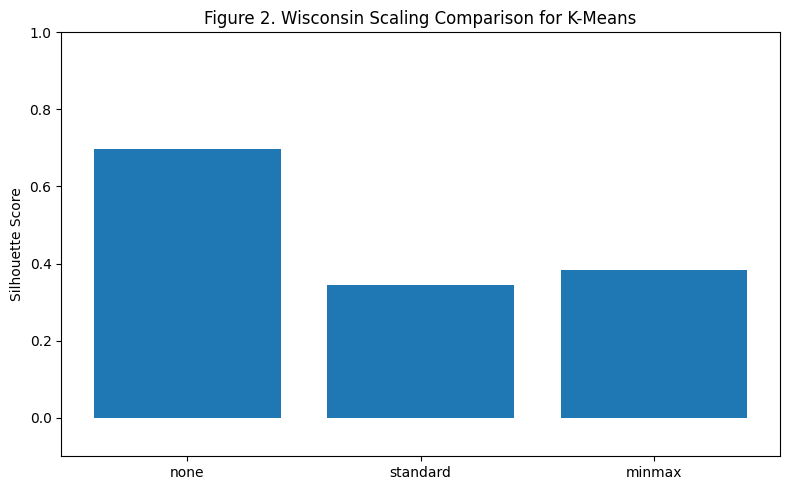

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(w_scaling_df["scaling"], w_scaling_df["silhouette_euclidean"])
plt.ylabel("Silhouette Score")
plt.title("Figure 2. Wisconsin Scaling Comparison for K-Means")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()


## 7. Wisconsin elbow method

I use the elbow method to examine inertia for different values of `k`. I look for where the curve begins to flatten.


In [8]:
X_w_standard = scale_data(X_w, "standard")
k_values = range(2, 11)

w_elbow_df = elbow_and_silhouette(X_w_standard, k_values)
w_elbow_df


,k,inertia,silhouette_euclidean
0,2,11595.461474,0.344974
1,3,10061.797818,0.314384
2,4,9257.362458,0.280336
3,5,8557.727454,0.158528
4,6,7970.263835,0.160367
5,7,7540.318697,0.153186
6,8,7192.191985,0.139234
7,9,6837.628936,0.147040
8,10,6603.404402,0.136656


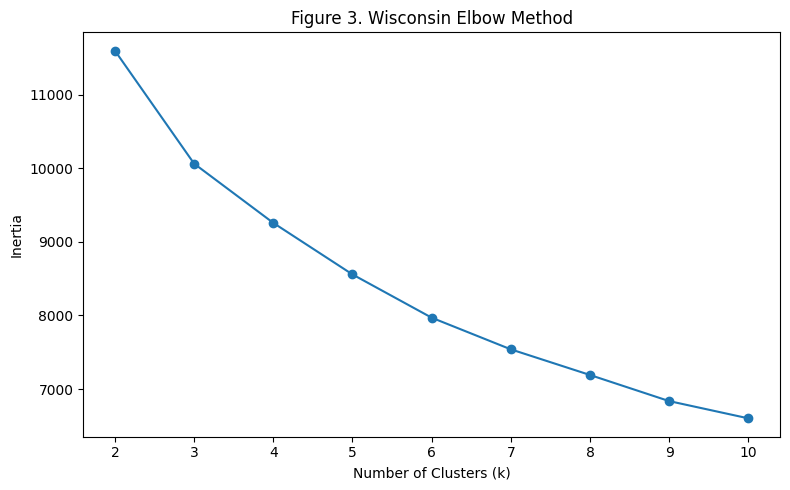

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(w_elbow_df["k"], w_elbow_df["inertia"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Figure 3. Wisconsin Elbow Method")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()


## 8. Wisconsin silhouette score

The silhouette score helps judge how separated the clusters are. Higher scores are better.


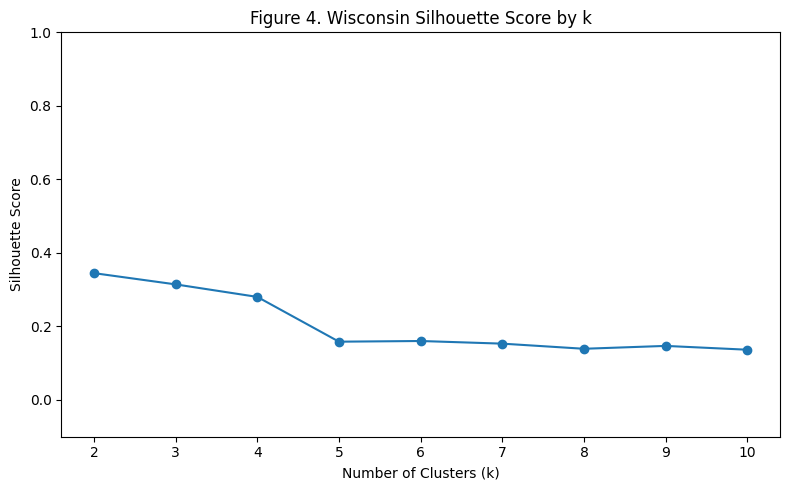

,k,inertia,silhouette_euclidean
0,2,11595.461474,0.344974
1,3,10061.797818,0.314384
2,4,9257.362458,0.280336
4,6,7970.263835,0.160367
3,5,8557.727454,0.158528
5,7,7540.318697,0.153186
7,9,6837.628936,0.147040
6,8,7192.191985,0.139234
8,10,6603.404402,0.136656


In [10]:
plt.figure(figsize=(8, 5))
plt.plot(w_elbow_df["k"], w_elbow_df["silhouette_euclidean"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Figure 4. Wisconsin Silhouette Score by k")
plt.xticks(list(k_values))
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()

w_elbow_df.sort_values("silhouette_euclidean", ascending=False)


## 9. Wisconsin final K-means model

I choose the `k` with the highest silhouette score. Then I compare the clusters to the known benign/malignant labels.


In [11]:
best_k_w = int(w_elbow_df.sort_values("silhouette_euclidean", ascending=False).iloc[0]["k"])
w_final_model, w_final_labels = run_kmeans(X_w_standard, best_k_w)

print("Best Wisconsin k based on silhouette:", best_k_w)

w_cluster_comparison = pd.crosstab(
    pd.Series(w_final_labels, name="cluster"),
    wisconsin_df["diagnosis_label"],
    margins=True
)

w_label_scores = compare_clusters_to_labels(w_final_labels, y_w, "Wisconsin")

display(w_cluster_comparison)
pd.DataFrame([w_label_scores])


Best Wisconsin k based on silhouette: 2


diagnosis_label,Benign,Malignant,All
cluster,,,
0,14,175,189
1,343,37,380
All,357,212,569


,dataset,adjusted_rand_index,normalized_mutual_info
0,Wisconsin,0.670721,0.554612


## 10. Wisconsin distance metrics

Standard K-means uses Euclidean distance, but I compare silhouette scores using Euclidean, Manhattan, and cosine distances for the final cluster labels.


In [12]:
w_distance_df = compare_distance_metrics(X_w_standard, w_final_labels)
w_distance_df


,distance_metric,silhouette_score
2,cosine,0.472550
1,manhattan,0.384686
0,euclidean,0.344974


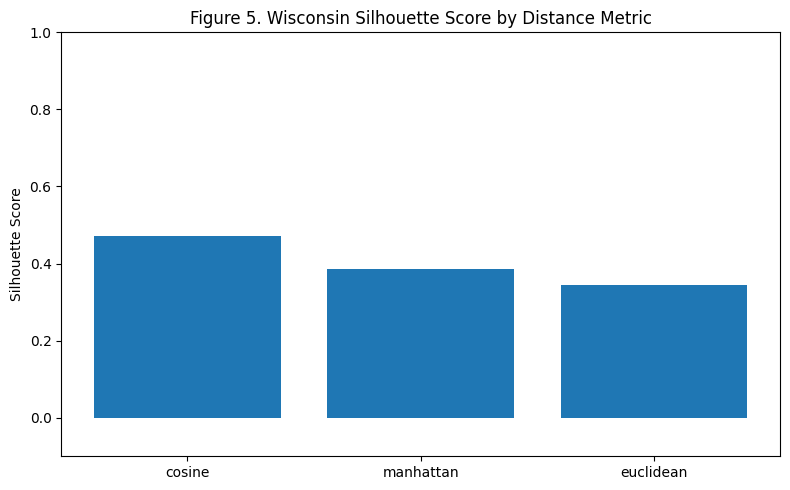

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(w_distance_df["distance_metric"], w_distance_df["silhouette_score"])
plt.ylabel("Silhouette Score")
plt.title("Figure 5. Wisconsin Silhouette Score by Distance Metric")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()


## 11. Wisconsin PCA visualization

PCA is used only for visualization. The K-means model was fit using all scaled features.


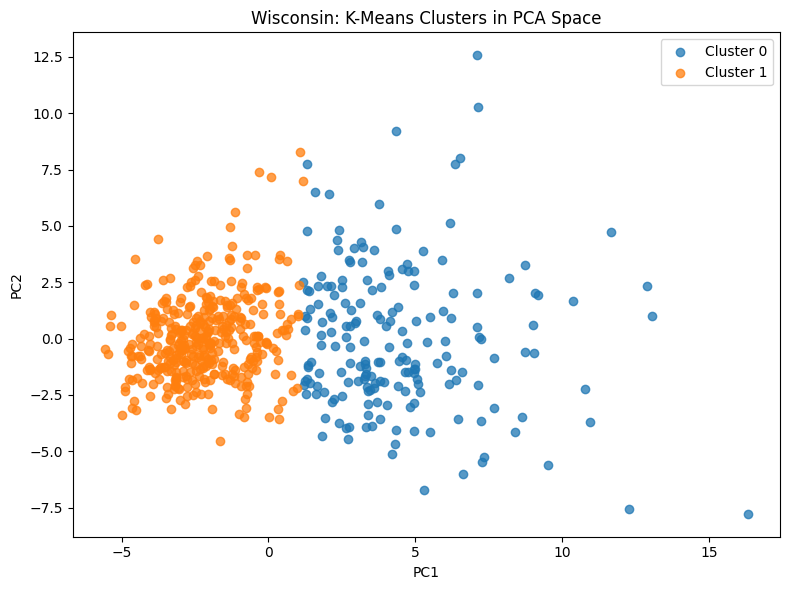

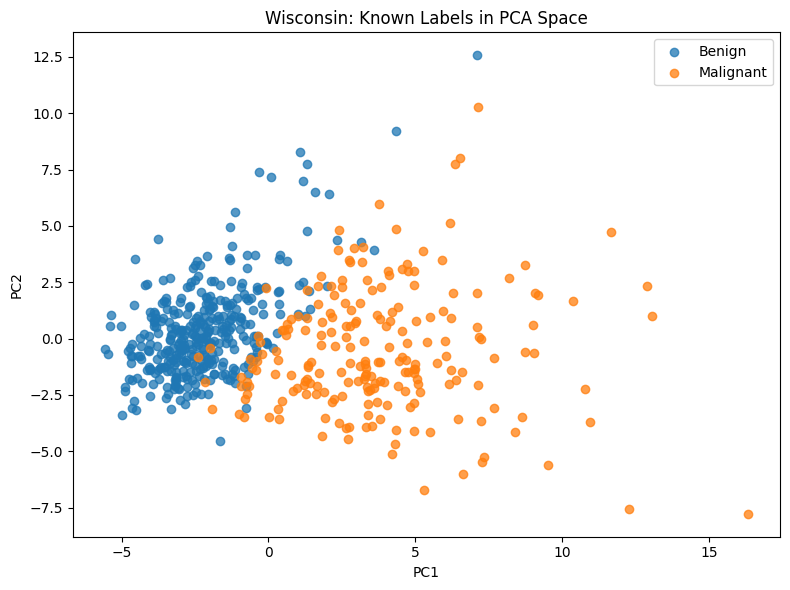

In [14]:
w_pca_df = plot_pca_view(
    X_w_standard,
    w_final_labels,
    y_w,
    "Wisconsin",
    {0: "Benign", 1: "Malignant"}
)


### Wisconsin interpretation

For Wisconsin, I expected K-means clusters to align somewhat with diagnosis because the tumor measurements are directly related to malignancy. However, K-means is unsupervised, so it is not trying to predict diagnosis. It only groups observations based on feature similarity.

If the clusters overlap with benign and malignant labels, that suggests the tumor measurements have natural structure related to diagnosis.


# Part B — Coimbra Dataset

## 12. Load Coimbra dataset

The Coimbra dataset target is `Classification`, where:

- `1 = Healthy controls`
- `2 = Breast cancer patients`

I recode it so that `1 = breast cancer patient` and `0 = healthy control`.


In [15]:
coimbra_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"

coimbra_df = pd.read_csv(coimbra_url)
coimbra_df.columns = (
    coimbra_df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace(".", "_", regex=False)
)

coimbra_df["breast_cancer_present"] = (coimbra_df["Classification"] == 2).astype(int)
coimbra_df["diagnosis_group"] = np.where(coimbra_df["breast_cancer_present"] == 1, "Patient", "Healthy Control")

print("Coimbra shape:", coimbra_df.shape)
print(coimbra_df["diagnosis_group"].value_counts())
print("\nMissing values:")
print(coimbra_df.isna().sum())

coimbra_df.head()


Coimbra shape: (116, 12)
diagnosis_group
Patient            64
Healthy Control    52
Name: count, dtype: int64

Missing values:
Age                      0
BMI                      0
Glucose                  0
Insulin                  0
HOMA                     0
Leptin                   0
Adiponectin              0
Resistin                 0
MCP_1                    0
Classification           0
breast_cancer_present    0
diagnosis_group          0
dtype: int64


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP_1,Classification,breast_cancer_present,diagnosis_group
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1,0,Healthy Control
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1,0,Healthy Control
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1,0,Healthy Control
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1,0,Healthy Control
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1,0,Healthy Control


## 13. Coimbra features and target label

The target label is only used after clustering to interpret whether the clusters resemble patient/control groups.


In [16]:
coimbra_features = [c for c in coimbra_df.columns if c not in ["Classification", "breast_cancer_present", "diagnosis_group"]]

X_c = coimbra_df[coimbra_features]
y_c = coimbra_df["breast_cancer_present"]

print("Coimbra rows:", X_c.shape[0])
print("Coimbra features:", X_c.shape[1])
print(coimbra_features)


Coimbra rows: 116
Coimbra features: 9
['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP_1']


## 14. Coimbra feature scaling check

Coimbra features are clinical and blood-based biomarkers, and they are measured on very different scales.


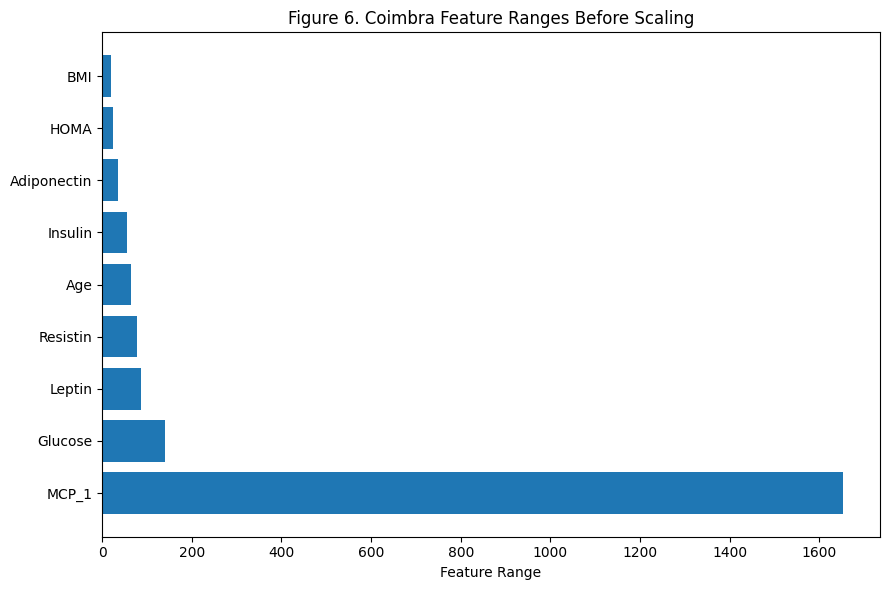

,min,max,mean,std,range
MCP_1,45.843000,1698.440000,534.647000,345.912663,1652.597000
Glucose,60.000000,201.000000,97.793103,22.525162,141.000000
Leptin,4.311000,90.280000,26.615080,19.183294,85.969000
Resistin,3.210000,82.100000,14.725966,12.390646,78.890000
Age,24.000000,89.000000,57.301724,16.112766,65.000000
Insulin,2.432000,58.460000,10.012086,10.067768,56.028000
Adiponectin,1.656020,38.040000,10.180874,6.843341,36.383980
HOMA,0.467409,25.050342,2.694988,3.642043,24.582933
BMI,18.370000,38.578759,27.582111,5.020136,20.208759


In [17]:
c_scale = X_c.agg(["min", "max", "mean", "std"]).T
c_scale["range"] = c_scale["max"] - c_scale["min"]
c_scale = c_scale.sort_values("range", ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(c_scale.index, c_scale["range"])
plt.xlabel("Feature Range")
plt.title("Figure 6. Coimbra Feature Ranges Before Scaling")
plt.tight_layout()
plt.show()

c_scale


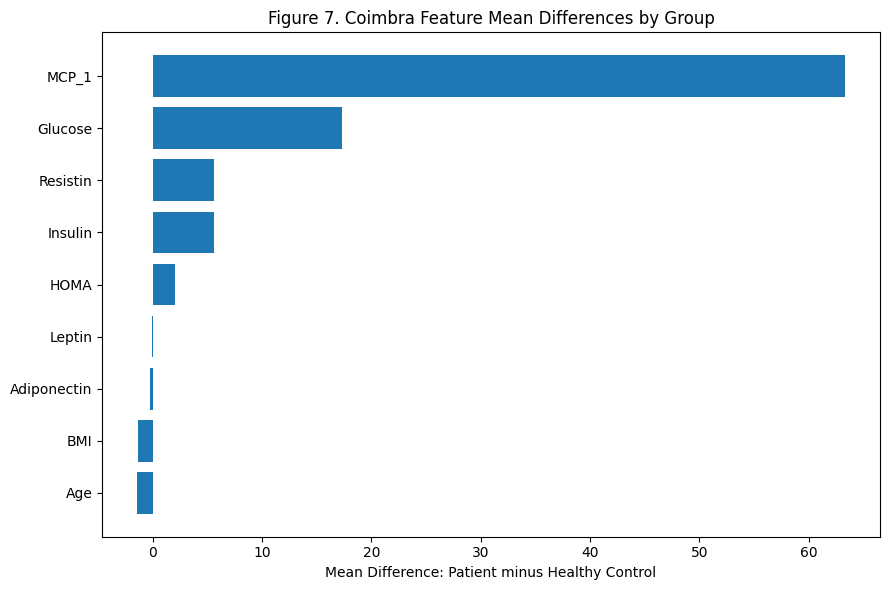

diagnosis_group,Healthy Control,Patient,difference_patient_minus_control
Age,58.076923,56.671875,-1.405048
BMI,28.317336,26.984740,-1.332596
Adiponectin,10.328205,10.061167,-0.267038
Leptin,26.637933,26.596512,-0.041420
HOMA,1.552398,3.623342,2.070944
Insulin,6.933769,12.513219,5.579450
Resistin,11.614813,17.253777,5.638964
Glucose,88.230769,105.562500,17.331731
MCP_1,499.730692,563.016500,63.285808


In [18]:
c_group_means = coimbra_df.groupby("diagnosis_group")[coimbra_features].mean().T
c_group_means["difference_patient_minus_control"] = c_group_means["Patient"] - c_group_means["Healthy Control"]

plot_df = c_group_means.sort_values("difference_patient_minus_control")

plt.figure(figsize=(9, 6))
plt.barh(plot_df.index, plot_df["difference_patient_minus_control"])
plt.xlabel("Mean Difference: Patient minus Healthy Control")
plt.title("Figure 7. Coimbra Feature Mean Differences by Group")
plt.tight_layout()
plt.show()

c_group_means.sort_values("difference_patient_minus_control")


## 15. Coimbra scaling comparison with k = 2

I compare no scaling, standard scaling, and min-max scaling with `k = 2`.


In [19]:
c_scaling_results = []

for method in ["none", "standard", "minmax"]:
    X_scaled = scale_data(X_c, method)
    model, labels = run_kmeans(X_scaled, k=2)
    c_scaling_results.append({
        "scaling": method,
        "inertia": model.inertia_,
        "silhouette_euclidean": silhouette_score(X_scaled, labels, metric="euclidean"),
        "adjusted_rand_index": adjusted_rand_score(y_c, labels),
        "normalized_mutual_info": normalized_mutual_info_score(y_c, labels)
    })

c_scaling_df = pd.DataFrame(c_scaling_results)
c_scaling_df.sort_values("silhouette_euclidean", ascending=False)


,scaling,inertia,silhouette_euclidean,adjusted_rand_index,normalized_mutual_info
0,none,5.522775e+06,0.573208,-0.008840,0.004384
1,standard,8.388271e+02,0.236727,0.001866,0.017052
2,minmax,3.212725e+01,0.203267,-0.008383,0.000104


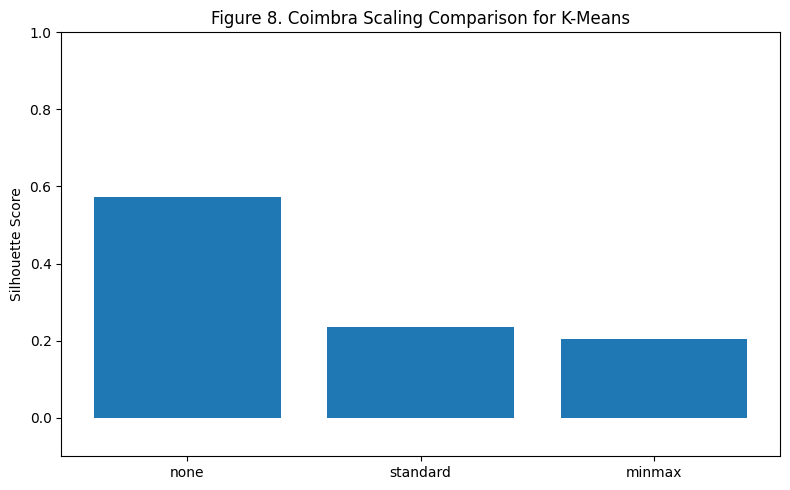

In [20]:
plt.figure(figsize=(8, 5))
plt.bar(c_scaling_df["scaling"], c_scaling_df["silhouette_euclidean"])
plt.ylabel("Silhouette Score")
plt.title("Figure 8. Coimbra Scaling Comparison for K-Means")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()


## 16. Coimbra elbow method

In [21]:
X_c_standard = scale_data(X_c, "standard")

c_elbow_df = elbow_and_silhouette(X_c_standard, k_values)
c_elbow_df


,k,inertia,silhouette_euclidean
0,2,838.827100,0.236727
1,3,698.234576,0.177388
2,4,612.520239,0.173927
3,5,544.464780,0.185935
4,6,494.378624,0.182839
5,7,450.851846,0.194602
6,8,418.302944,0.155148
7,9,382.302260,0.170985
8,10,358.597163,0.174461


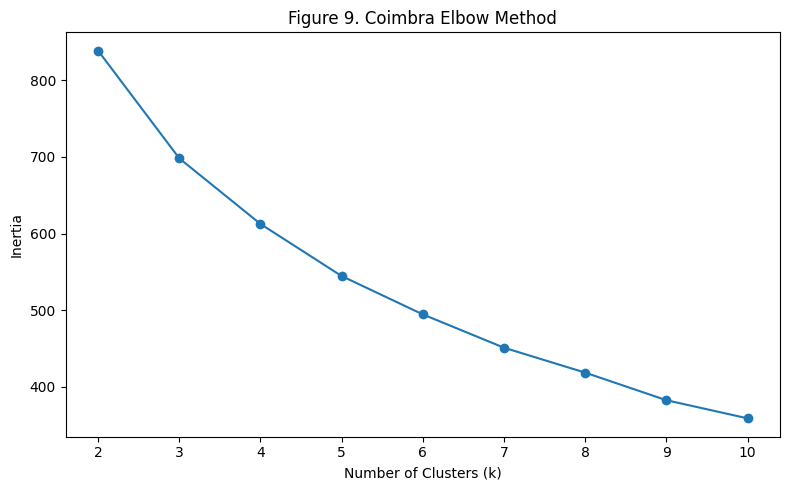

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(c_elbow_df["k"], c_elbow_df["inertia"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Figure 9. Coimbra Elbow Method")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()


## 17. Coimbra silhouette score

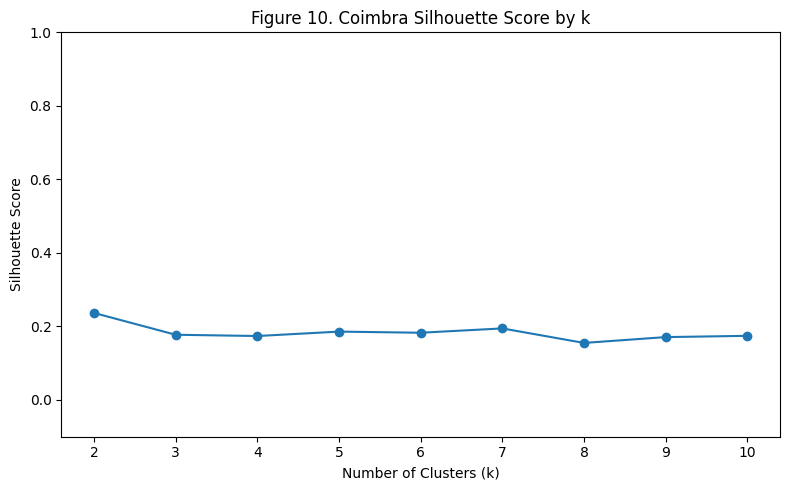

,k,inertia,silhouette_euclidean
0,2,838.827100,0.236727
5,7,450.851846,0.194602
3,5,544.464780,0.185935
4,6,494.378624,0.182839
1,3,698.234576,0.177388
8,10,358.597163,0.174461
2,4,612.520239,0.173927
7,9,382.302260,0.170985
6,8,418.302944,0.155148


In [23]:
plt.figure(figsize=(8, 5))
plt.plot(c_elbow_df["k"], c_elbow_df["silhouette_euclidean"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Figure 10. Coimbra Silhouette Score by k")
plt.xticks(list(k_values))
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()

c_elbow_df.sort_values("silhouette_euclidean", ascending=False)


## 18. Coimbra final K-means model

In [24]:
best_k_c = int(c_elbow_df.sort_values("silhouette_euclidean", ascending=False).iloc[0]["k"])
c_final_model, c_final_labels = run_kmeans(X_c_standard, best_k_c)

print("Best Coimbra k based on silhouette:", best_k_c)

c_cluster_comparison = pd.crosstab(
    pd.Series(c_final_labels, name="cluster"),
    coimbra_df["diagnosis_group"],
    margins=True
)

c_label_scores = compare_clusters_to_labels(c_final_labels, y_c, "Coimbra")

display(c_cluster_comparison)
pd.DataFrame([c_label_scores])


Best Coimbra k based on silhouette: 2


diagnosis_group,Healthy Control,Patient,All
cluster,,,
0,39,39,78
1,13,25,38
All,52,64,116


,dataset,adjusted_rand_index,normalized_mutual_info
0,Coimbra,0.001866,0.017052


## 19. Coimbra distance metrics

In [25]:
c_distance_df = compare_distance_metrics(X_c_standard, c_final_labels)
c_distance_df


,distance_metric,silhouette_score
2,cosine,0.304800
1,manhattan,0.264969
0,euclidean,0.236727


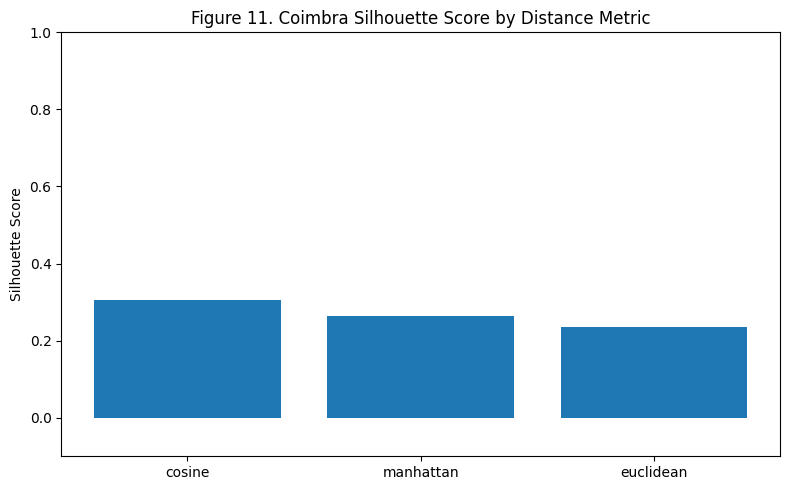

In [26]:
plt.figure(figsize=(8, 5))
plt.bar(c_distance_df["distance_metric"], c_distance_df["silhouette_score"])
plt.ylabel("Silhouette Score")
plt.title("Figure 11. Coimbra Silhouette Score by Distance Metric")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()


## 20. Coimbra PCA visualization

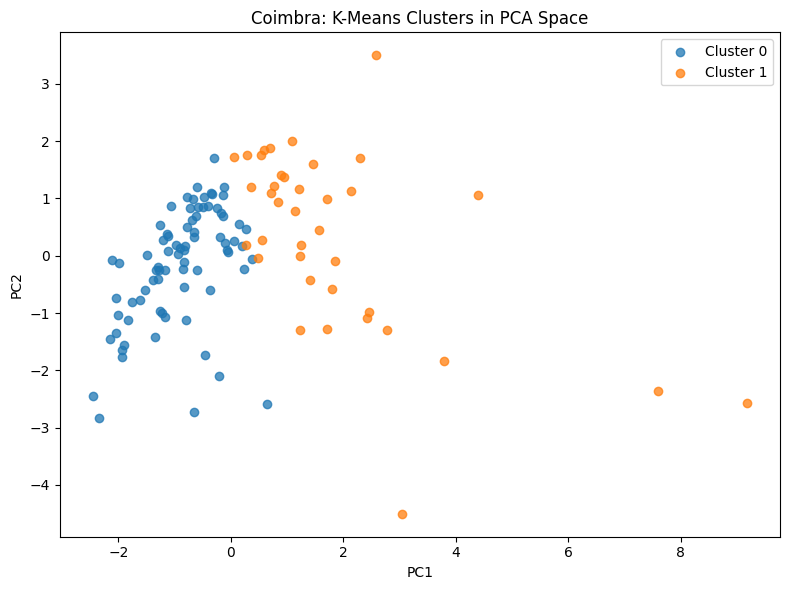

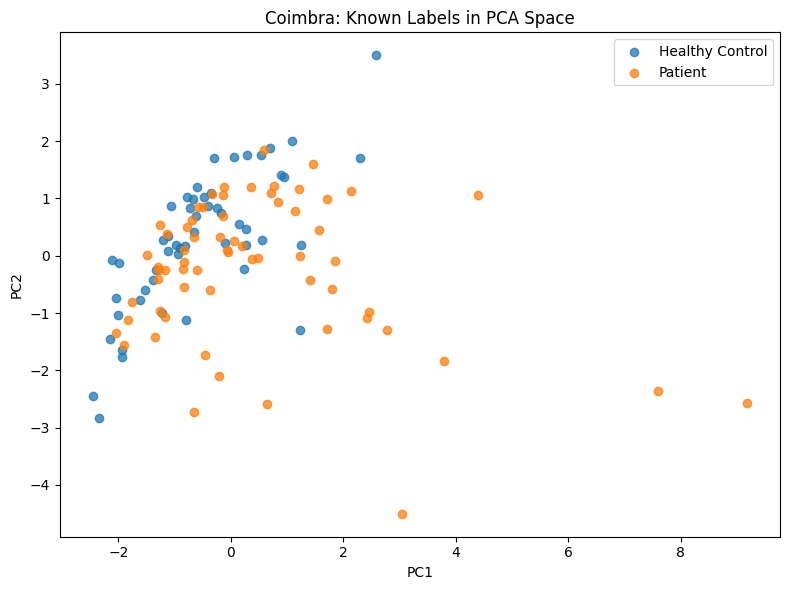

In [27]:
c_pca_df = plot_pca_view(
    X_c_standard,
    c_final_labels,
    y_c,
    "Coimbra",
    {0: "Healthy Control", 1: "Patient"}
)


### Coimbra interpretation

For Coimbra, I expected weaker cluster separation than Wisconsin because the features are indirect biomarkers rather than tumor image measurements. K-means may still find patient profiles, but those profiles may not align perfectly with healthy control versus breast cancer patient status.


# Part C — Cross-Dataset Comparison

## 21. Wisconsin vs. Coimbra comparison

Now I compare the final K-means results across both datasets.


In [28]:
combined_summary = pd.DataFrame([
    {
        "dataset": "Wisconsin",
        "best_k": best_k_w,
        "silhouette_euclidean": silhouette_score(X_w_standard, w_final_labels, metric="euclidean"),
        "adjusted_rand_index": adjusted_rand_score(y_w, w_final_labels),
        "normalized_mutual_info": normalized_mutual_info_score(y_w, w_final_labels)
    },
    {
        "dataset": "Coimbra",
        "best_k": best_k_c,
        "silhouette_euclidean": silhouette_score(X_c_standard, c_final_labels, metric="euclidean"),
        "adjusted_rand_index": adjusted_rand_score(y_c, c_final_labels),
        "normalized_mutual_info": normalized_mutual_info_score(y_c, c_final_labels)
    }
])

combined_summary


,dataset,best_k,silhouette_euclidean,adjusted_rand_index,normalized_mutual_info
0,Wisconsin,2,0.344974,0.670721,0.554612
1,Coimbra,2,0.236727,0.001866,0.017052


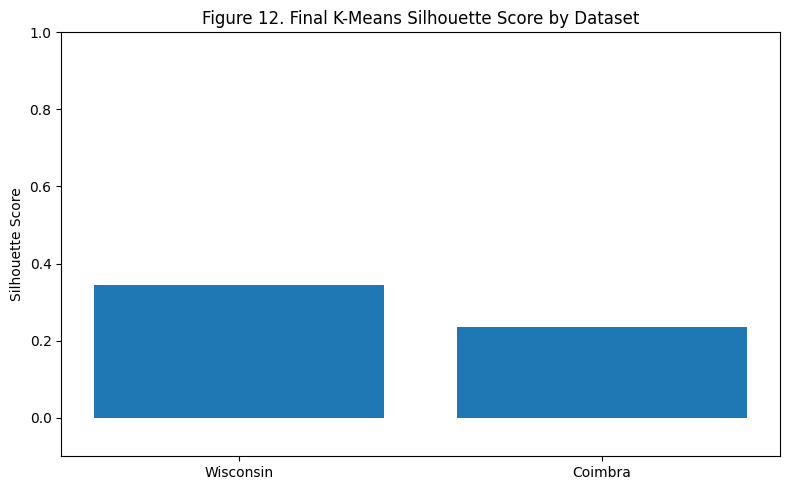

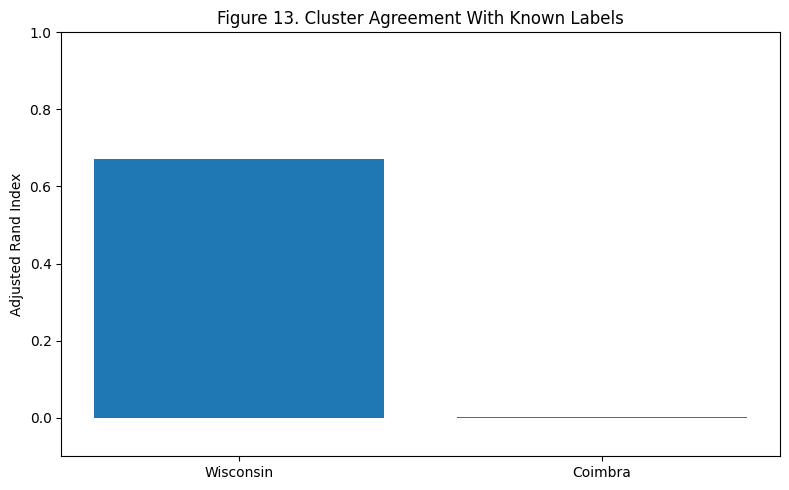

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(combined_summary["dataset"], combined_summary["silhouette_euclidean"])
plt.ylabel("Silhouette Score")
plt.title("Figure 12. Final K-Means Silhouette Score by Dataset")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(combined_summary["dataset"], combined_summary["adjusted_rand_index"])
plt.ylabel("Adjusted Rand Index")
plt.title("Figure 13. Cluster Agreement With Known Labels")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()


## 22. Week 10 summary

In [31]:
print("Week 10 K-Means Summary")


print("Wisconsin:")
print(f"Best k: {best_k_w}")
print(f"Silhouette score: {combined_summary.loc[combined_summary['dataset']=='Wisconsin', 'silhouette_euclidean'].iloc[0]:.4f}")
print(f"Adjusted Rand Index: {combined_summary.loc[combined_summary['dataset']=='Wisconsin', 'adjusted_rand_index'].iloc[0]:.4f}")

print("\nCoimbra:")
print(f"Best k: {best_k_c}")
print(f"Silhouette score: {combined_summary.loc[combined_summary['dataset']=='Coimbra', 'silhouette_euclidean'].iloc[0]:.4f}")
print(f"Adjusted Rand Index: {combined_summary.loc[combined_summary['dataset']=='Coimbra', 'adjusted_rand_index'].iloc[0]:.4f}")

print("\nInterpretation:")
print("K-means does not use diagnosis labels. The label comparison is only used afterward to see whether natural clusters resemble known outcomes.")


Week 10 K-Means Summary
Wisconsin:
Best k: 2
Silhouette score: 0.3450
Adjusted Rand Index: 0.6707

Coimbra:
Best k: 2
Silhouette score: 0.2367
Adjusted Rand Index: 0.0019

Interpretation:
K-means does not use diagnosis labels. The label comparison is only used afterward to see whether natural clusters resemble known outcomes.


## 23. Week 10 findings and interpretation

This week showed me that clustering answers a different question from the supervised models in earlier weeks. Supervised models ask whether the model can predict the known label. K-means asks whether the observations naturally group together based only on their features.

Feature scaling was one of the most important parts of this notebook. Since K-means is distance-based, variables with large numeric ranges can dominate the clustering if scaling is not applied. This affected both datasets. In Wisconsin, tumor area and perimeter have much larger ranges than smoothness or symmetry. In Coimbra, MCP-1 and insulin have much larger ranges than age or BMI.

The elbow method helped me inspect how inertia changed as the number of clusters increased. However, the elbow method can be subjective, so I also used the silhouette score as a more numeric way to compare cluster separation. I also compared silhouette scores under different distance metrics. Standard K-means uses Euclidean distance, but checking Manhattan and cosine silhouette scores helped me understand how cluster quality changes depending on how distance is measured.

For the Wisconsin dataset, I expected stronger cluster alignment with diagnosis because tumor morphology features are directly related to benign versus malignant tumors. For Coimbra, I expected weaker alignment because biomarkers are more indirect and the dataset is smaller. Overall, the comparison helps show that tumor image-based data may contain stronger natural structure related to diagnosis than clinical biomarker data.


## 24. References

UCI Machine Learning Repository. (n.d.). *Breast Cancer Wisconsin (Diagnostic) dataset*. https://doi.org/10.24432/C5DW2B

Patrício, M., Pereira, J., Crisóstomo, J., Matafome, P., Seiça, R., & Caramelo, F. (2018). *Breast Cancer Coimbra* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P59

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Scikit-learn developers. (n.d.). *K-means*. https://scikit-learn.org/stable/modules/clustering.html#k-means

Scikit-learn developers. (n.d.). *Silhouette coefficient*. https://scikit-learn.org/stable/modules/clustering.html#silhouette-coefficient
